# $A(x+y,z) = A(x,z) + A(y,z)$ — три шага на рисунке

**Сверху слева** — только первое слагаемое: параллелограмм на $x$ и $z$ из $O$ (синий).

**Сверху справа** — только второе: параллелограмм на $y$ и $z$ из $O$ (зелёный). Та же фигура потом **сдвигается** на вектор $x$.

**Снизу (на всю ширину)** — оба куска рядом: синий у $O$, зелёный от точки $x$; чёрная обводка — граница **целого** параллелограмма на $x+y$ и $z$. Числа внизу: площади складываются.

$A(u,v)$ — ориентированная площадь (здесь считаем как `det2`).

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def parallelogram_from_edges(origin, u, v):
    """Вершины: O, O+u, O+u+v, O+v (обход против часовой, если u,v — правая пара)."""
    O = np.asarray(origin, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    return np.array([O, O + u, O + u + v, O + v])


def det2(a, b):
    """Ориентированная площадь: det([a b]) для столбцов a, b."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[0] * b[1] - a[1] * b[0]

In [17]:
# z — горизонтально, чтобы картинка читалась; x, y подобраны так, что det(x+y,z)=det(x,z)+det(y,z)
O = np.array([0.0, 0.0])
z = np.array([5.0, 0.0])
x = np.array([2.0, 2.0])
y = np.array([1.5, 1.0])
xp = x + y

poly_xz = parallelogram_from_edges(O, x, z)
poly_yz_O = parallelogram_from_edges(O, y, z)
poly_yz_shifted = parallelogram_from_edges(x, y, z)
poly_sum = parallelogram_from_edges(O, xp, z)

d_xz = det2(x, z)
d_yz = det2(y, z)
d_sum = det2(xp, z)
print("Проверка: A(x,z) + A(y,z) =", d_xz + d_yz, "  A(x+y,z) =", d_sum)

Проверка: A(x,z) + A(y,z) = -15.0   A(x+y,z) = -15.0


/var/folders/zk/wc07fm1d6sx_8362cmm1sh1xybjh0x/T/ipykernel_86738/4065842669.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.95])


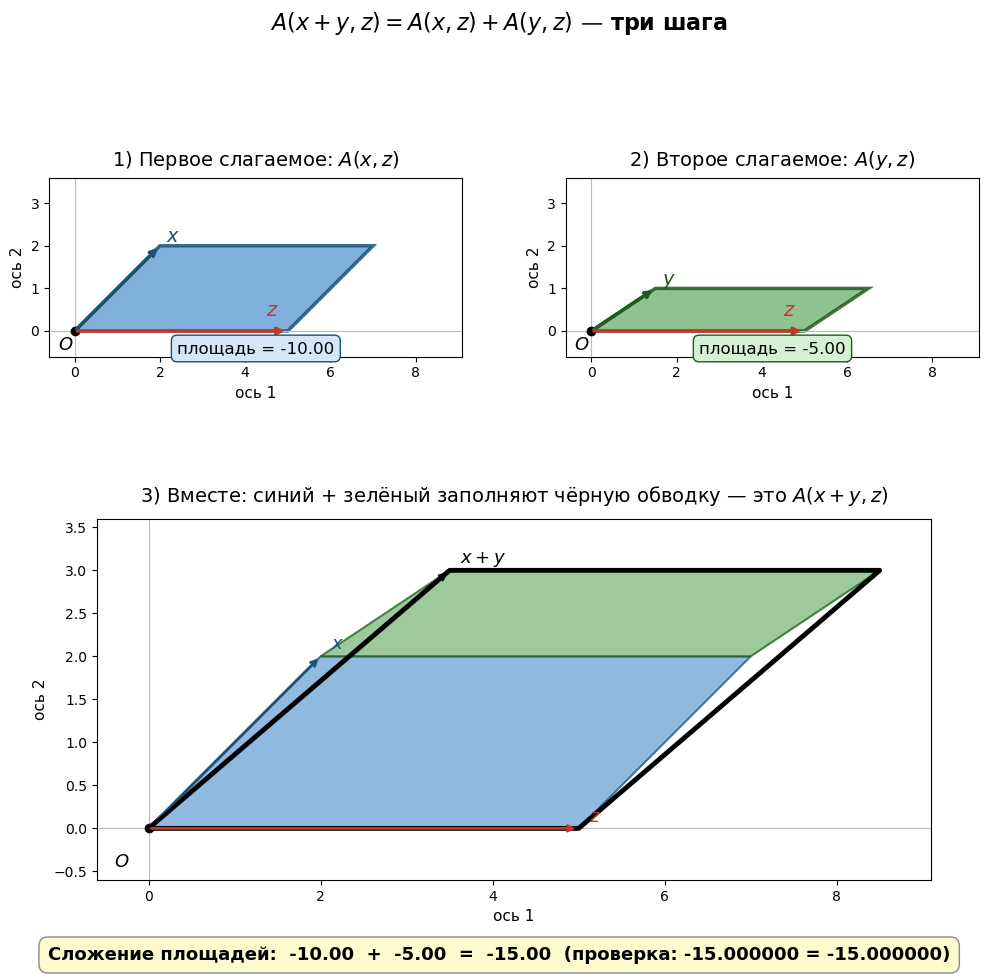

In [18]:
def _lims(*polys, pad=0.6):
    pts = np.vstack(polys)
    x0, y0 = pts.min(axis=0) - pad
    x1, y1 = pts.max(axis=0) + pad
    return (x0, x1), (y0, y1)


# Общие пределы для всех трёх картинок — один масштаб
xl, yl = _lims(poly_xz, poly_yz_O, poly_yz_shifted, poly_sum)


def draw_axes(ax):
    ax.set_aspect("equal")
    ax.axhline(0, color="#bbb", lw=0.8)
    ax.axvline(0, color="#bbb", lw=0.8)
    ax.set_xlim(*xl)
    ax.set_ylim(*yl)
    ax.set_xlabel("ось 1", fontsize=11)
    ax.set_ylabel("ось 2", fontsize=11)


fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], hspace=0.28, wspace=0.25)

# --- 1) только A(x,z) ---
ax1 = fig.add_subplot(gs[0, 0])
draw_axes(ax1)
ax1.add_patch(
    Polygon(
        poly_xz,
        closed=True,
        facecolor="#6BA3D6",
        edgecolor="#1a5275",
        linewidth=2.5,
        alpha=0.85,
    )
)
ax1.annotate("", xy=x, xytext=O, arrowprops=dict(arrowstyle="->", color="#1a5275", lw=2.5))
ax1.annotate("", xy=z, xytext=O, arrowprops=dict(arrowstyle="->", color="#c0392b", lw=2.5))
ax1.text(x[0] + 0.15, x[1] + 0.08, r"$x$", fontsize=14, color="#1a5275", fontweight="bold")
ax1.text(z[0] - 0.5, z[1] + 0.35, r"$z$", fontsize=14, color="#c0392b", fontweight="bold")
ax1.plot(0, 0, "ko", ms=6)
ax1.text(-0.4, -0.45, r"$O$", fontsize=13)
ax1.set_title("1) Первое слагаемое: $A(x,z)$", fontsize=14, pad=8)
ax1.text(
    0.5,
    0.02,
    f"площадь = {d_xz:.2f}",
    transform=ax1.transAxes,
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#d4e6f7", edgecolor="#1a5275"),
)

# --- 2) только A(y,z) в O ---
ax2 = fig.add_subplot(gs[0, 1])
draw_axes(ax2)
ax2.add_patch(
    Polygon(
        poly_yz_O,
        closed=True,
        facecolor="#7CB87C",
        edgecolor="#1e5c1e",
        linewidth=2.5,
        alpha=0.85,
    )
)
ax2.annotate("", xy=y, xytext=O, arrowprops=dict(arrowstyle="->", color="#1e5c1e", lw=2.5))
ax2.annotate("", xy=z, xytext=O, arrowprops=dict(arrowstyle="->", color="#c0392b", lw=2.5))
ax2.text(y[0] + 0.15, y[1] + 0.08, r"$y$", fontsize=14, color="#1e5c1e", fontweight="bold")
ax2.text(z[0] - 0.5, z[1] + 0.35, r"$z$", fontsize=14, color="#c0392b", fontweight="bold")
ax2.plot(0, 0, "ko", ms=6)
ax2.text(-0.4, -0.45, r"$O$", fontsize=13)
ax2.set_title("2) Второе слагаемое: $A(y,z)$", fontsize=14, pad=8)
ax2.text(
    0.5,
    0.02,
    f"площадь = {d_yz:.2f}",
    transform=ax2.transAxes,
    ha="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#d5f0d5", edgecolor="#1e5c1e"),
)

# --- 3) склейка: синий + зелёный (сдвинутый) = весь параллелограмм ---
ax3 = fig.add_subplot(gs[1, :])
draw_axes(ax3)
ax3.add_patch(
    Polygon(
        poly_xz,
        closed=True,
        facecolor="#6BA3D6",
        edgecolor="#1a5275",
        linewidth=1.5,
        alpha=0.75,
    )
)
ax3.add_patch(
    Polygon(
        poly_yz_shifted,
        closed=True,
        facecolor="#7CB87C",
        edgecolor="#1e5c1e",
        linewidth=1.5,
        alpha=0.75,
    )
)
ax3.plot(
    np.append(poly_sum[:, 0], poly_sum[0, 0]),
    np.append(poly_sum[:, 1], poly_sum[0, 1]),
    "k-",
    lw=3.5,
)

# векторы подписи
for v, name, col in [(x, "x", "#1a5275"), (x + y, "x+y", "black"), (z, "z", "#c0392b")]:
    ax3.annotate("", xy=v, xytext=O, arrowprops=dict(arrowstyle="->", color=col, lw=2))
    ax3.text(v[0] + 0.12, v[1] + 0.08, f"${name}$", fontsize=13, color=col, fontweight="bold")
ax3.plot(0, 0, "ko", ms=6)
ax3.text(-0.4, -0.45, r"$O$", fontsize=13)

ax3.set_title(
    "3) Вместе: синий + зелёный заполняют чёрную обводку — это $A(x+y,z)$",
    fontsize=14,
    pad=12,
)

# полоска «сложение площадей»
sum_txt = f"{d_xz:.2f}  +  {d_yz:.2f}  =  {d_sum:.2f}"
fig.text(
    0.5,
    0.03,
    f"Сложение площадей:  {sum_txt}  (проверка: {d_xz + d_yz:.6f} = {d_sum:.6f})",
    ha="center",
    fontsize=13,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fffacd", edgecolor="#888"),
)

plt.suptitle(
    r"$A(x+y,z) = A(x,z) + A(y,z)$ — три шага",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

**Как читать рисунок:** сверху — два отдельных параллелограмма (площади в рамках). Снизу — они стоят рядом: зелёный **тот же**, что наверху справа, только начало перенесено из $O$ в конец вектора $x$. Чёрная обводка — целиком $A(x+y,z)$. Жёлтая полоска внизу — сложение чисел.

**Почему так:** не «делим пополам», а **склеиваем** два параллелограмма по общей стороне (от $x$ до $x+z$).